# Bài tập Chapter 3: Canny · Multi-scale Hough · RANSAC

Tự cài đặt bằng NumPy — **không** dùng `cv2.Canny`, Hough/RANSAC có sẵn ở phần cốt lõi.

Lý thuyết: [`Computer_Vision 24.pdf`](./Computer_Vision%2024.pdf)

# Thiết lập chung

In [7]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    cv2 = None

%matplotlib inline

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'gray'

In [8]:
def show_image(img, title='', cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_images(images, titles=None, cols=3, cmap='gray', figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_grayscale(img):
    """Chuyển ảnh sang grayscale float64 [0, 255]."""
    arr = np.asarray(img, dtype=np.float64)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3 and arr.shape[2] >= 3:
        return 0.299 * arr[..., 0] + 0.587 * arr[..., 1] + 0.114 * arr[..., 2]
    raise ValueError('Anh dau vao phai la grayscale hoac RGB')

# Bài 1: Canny từ đầu

## Pipeline (PDF §1.4)

1. Gaussian blur (σ)
2. Sobel → Gx, Gy, M, θ
3. Non-maximum suppression *(Tuyền)*
4. Hysteresis + Otsu *(Trường)*

## Duy — Gaussian blur + Sobel (§1.4.1–1.4.2)

In [9]:
def convolve2d_reflect(img, kernel):
    """Tích chập 2D, pad reflect — dùng cho Gaussian và Sobel."""
    img = np.asarray(img, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(img, dtype=np.float64)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            patch = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(patch * kernel)
    return out


def gaussian_kernel_2d(sigma):
    """Kernel Gaussian 2D chuẩn hoá tổng = 1 (PDF §1.4.1)."""
    if sigma <= 0:
        raise ValueError('sigma phai > 0')
    r = int(3 * sigma + 0.5)
    ax = np.arange(-r, r + 1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kern = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    s = kern.sum()
    if s == 0:
        raise ValueError('kernel Gaussian khong hop le')
    return kern / s


def gaussian_blur(img, sigma=1.4):
    """
    Làm mờ Gaussian trước khi tính gradient (blur trước, Sobel sau).
    img: grayscale float hoặc ảnh màu (tự chuyển grayscale).
    """
    gray = to_grayscale(img)
    kernel = gaussian_kernel_2d(float(sigma))
    return convolve2d_reflect(gray, kernel)


def sobel_gradients(img):
    """
    Sobel trên ảnh đã blur. Trả về Gx, Gy, M, theta (rad).
    M = sqrt(Gx^2 + Gy^2) — không dùng |Gx| + |Gy| (PDF §1.3).
    theta vuông góc với cạnh; dùng arctan2(Gy, Gx).
    """
    gray = to_grayscale(img)
    kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float64)
    ky = kx.T
    gx = convolve2d_reflect(gray, kx)
    gy = convolve2d_reflect(gray, ky)
    magnitude = np.hypot(gx, gy)
    theta = np.arctan2(gy, gx)
    return gx, gy, magnitude, theta

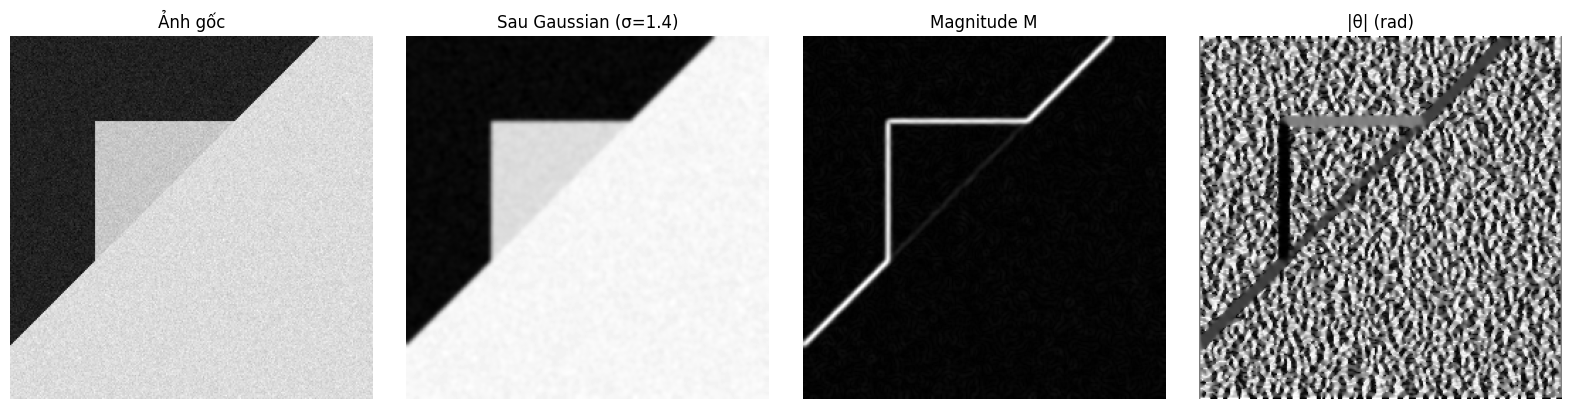

In [10]:
def make_test_edges(size=256):
    """Ảnh mức xám có hình vuông và đường chéo — kiểm thử gradient."""
    img = np.full((size, size), 40.0, dtype=np.float64)
    img[60:180, 60:180] = 200.0
    y, x = np.mgrid[0:size, 0:size]
    mask = (x + y) > size * 0.85
    img[mask] = 220.0
    rng = np.random.default_rng(0)
    img += rng.normal(0, 8, img.shape)
    return np.clip(img, 0, 255)


test_img = make_test_edges()
sigma = 1.4
blurred = gaussian_blur(test_img, sigma=sigma)
gx, gy, mag, theta = sobel_gradients(blurred)

show_images(
    [test_img, blurred, mag, np.abs(theta)],
    titles=['Ảnh gốc', f'Sau Gaussian (σ={sigma})', 'Magnitude M', '|θ| (rad)'],
    cols=4,
    figsize=(16, 4)
)

## Tuyền — Non-maximum Suppression (§1.4.3)

Lượng hoá θ về 0°/45°/90°/135°; so sánh M(p) với 2 hàng xóm dọc hướng gradient (θ vuông góc cạnh).

In [11]:
def non_maximum_suppression(magnitude, theta):
    """Làm mỏng biên: giữ pixel cực đại cục bộ theo hướng gradient (PDF §1.4.3)."""
    M = magnitude.astype(np.float64)
    Z = np.zeros_like(M)
    angle = np.rad2deg(theta) % 180.0
    h, w = M.shape
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            a = angle[i, j]
            if (0 <= a < 22.5) or (157.5 <= a <= 180):
                n1, n2 = M[i, j + 1], M[i, j - 1]
            elif 22.5 <= a < 67.5:
                n1, n2 = M[i + 1, j - 1], M[i - 1, j + 1]
            elif 67.5 <= a < 112.5:
                n1, n2 = M[i + 1, j], M[i - 1, j]
            else:
                n1, n2 = M[i - 1, j - 1], M[i + 1, j + 1]
            if M[i, j] >= n1 and M[i, j] >= n2:
                Z[i, j] = M[i, j]
    return Z

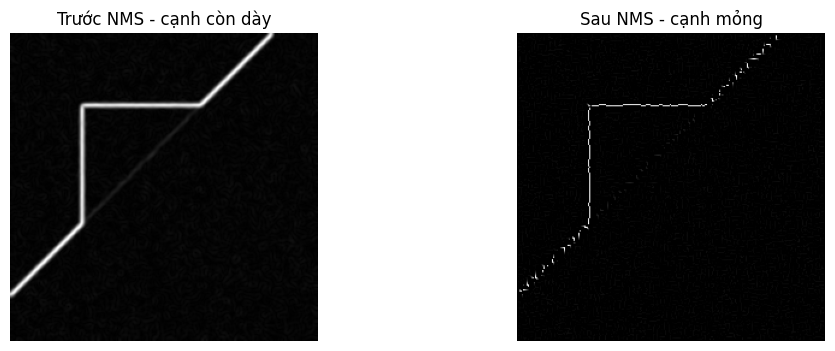

In [12]:
nms = non_maximum_suppression(mag, theta)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(mag, cmap="gray")
plt.title("Trước NMS - cạnh còn dày")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(nms, cmap="gray")
plt.title("Sau NMS - cạnh mỏng")
plt.axis("off")

plt.show()

## Trường — Hysteresis + Otsu + pipeline Canny (§1.4.4–1.6)

In [13]:
from collections import deque


def hysteresis_threshold(magnitude, low, high):
    """Double threshold + BFS nối weak edge với strong edge (PDF §1.4.4)."""
    strong = magnitude >= high
    weak = (magnitude >= low) & ~strong
    edges = np.zeros_like(magnitude, dtype=np.uint8)
    edges[strong] = 255
    q = deque(zip(*np.nonzero(strong)))
    weak_mask = weak.copy()
    while q:
        i, j = q.popleft()
        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                if di == 0 and dj == 0:
                    continue
                ni, nj = i + di, j + dj
                if 0 <= ni < edges.shape[0] and 0 <= nj < edges.shape[1] and weak_mask[ni, nj]:
                    edges[ni, nj] = 255
                    weak_mask[ni, nj] = False
                    q.append((ni, nj))
    return edges


def otsu_threshold(magnitude, nbins=256):
    """Otsu trên histogram M: tau_high = tau*, tau_low = tau_high/2 (PDF §1.5)."""
    vals = magnitude.ravel()
    vmax = max(float(vals.max()), 1.0)
    hist, edges_bin = np.histogram(vals, bins=nbins, range=(0, vmax))
    total = hist.sum()
    if total == 0:
        return 0.0, 0.0, hist, edges_bin
    prob = hist.astype(np.float64) / total
    bins = (edges_bin[:-1] + edges_bin[1:]) / 2.0
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * bins)
    mu_t = mu[-1]
    sigma_b = (mu_t * omega - mu) ** 2 / (omega * (1.0 - omega) + 1e-12)
    sigma_b = np.nan_to_num(sigma_b)
    idx = int(np.argmax(sigma_b))
    tau_high = float(bins[idx])
    return tau_high, tau_high / 2.0, hist, edges_bin


def plot_magnitude_histogram(magnitude, tau_high=None, title='Histogram M'):
    tau_h, tau_l, hist, edges_bin = otsu_threshold(magnitude)
    if tau_high is None:
        tau_high = tau_h
    centers = (edges_bin[:-1] + edges_bin[1:]) / 2.0
    plt.figure(figsize=(8, 3))
    plt.bar(centers, hist, width=centers[1] - centers[0], color='steelblue', alpha=0.8)
    plt.axvline(tau_high, color='red', ls='--', label=f'tau_high={tau_high:.1f}')
    plt.axvline(tau_high / 2.0, color='orange', ls='--', label=f'tau_low={tau_high/2:.1f}')
    plt.xlabel('Magnitude M')
    plt.ylabel('Số pixel')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return tau_h, tau_l


def canny_from_scratch(img, sigma=1.4, low_ratio=0.5, use_otsu=True, low=None, high=None):
    """Ghép đầy đủ pipeline Canny từ đầu (PDF §1.4)."""
    blurred = gaussian_blur(img, sigma)
    _, _, mag, theta = sobel_gradients(blurred)
    thin = non_maximum_suppression(mag, theta)
    if use_otsu:
        high, low, _, _ = otsu_threshold(mag)
    elif high is None or low is None:
        high = 0.3 * thin.max()
        low = high * low_ratio
    edges = hysteresis_threshold(thin, low, high)
    return edges, thin, mag


def compute_iou(edges_a, edges_b):
    a = np.asarray(edges_a) > 0
    b = np.asarray(edges_b) > 0
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union > 0 else 0.0

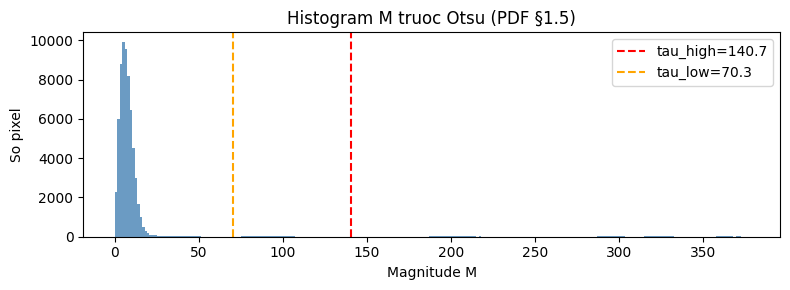

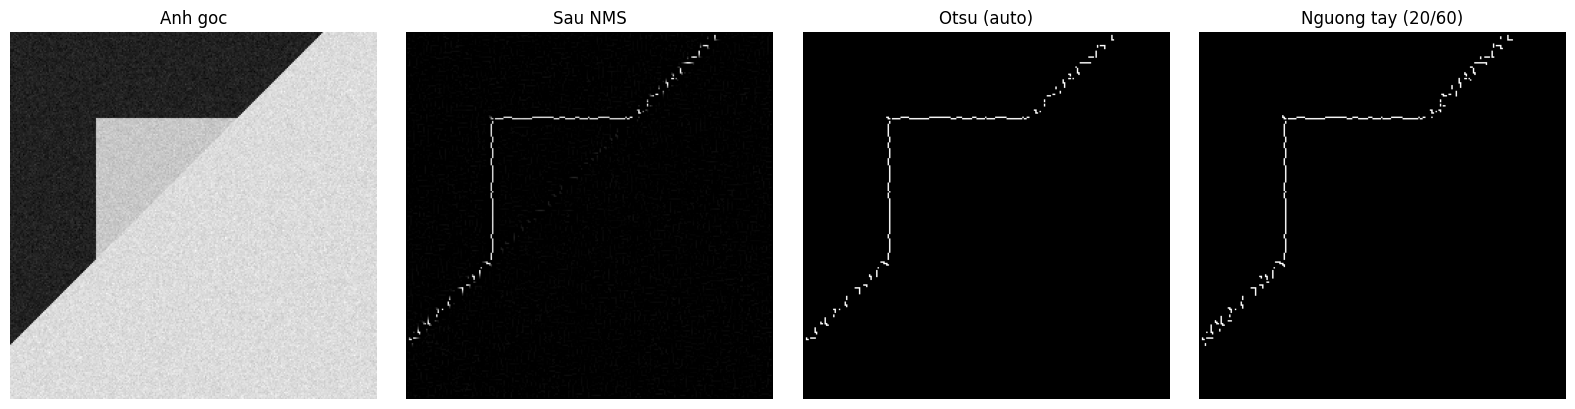

IoU (Otsu vs cv2.Canny): 0.1331738437001595
IoU (tay vs cv2.Canny): 0.13026819923371646


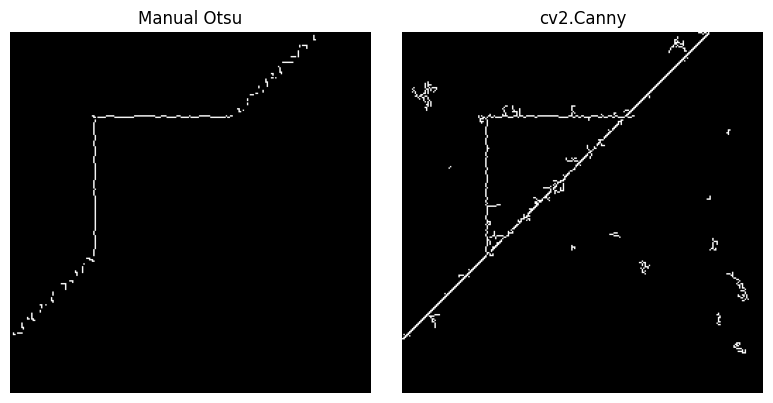

In [14]:
# Demo Trường — Otsu + hysteresis + so sánh ngưỡng tay
edges_otsu, nms_thin, mag_used = canny_from_scratch(test_img, sigma=1.4, use_otsu=True)
plot_magnitude_histogram(mag_used, title='Histogram M truoc Otsu (PDF §1.5)')

edges_manual, _, _ = canny_from_scratch(test_img, sigma=1.4, use_otsu=False, low=20, high=60)
show_images(
    [test_img, nms_thin, edges_otsu, edges_manual],
    ['Anh goc', 'Sau NMS', 'Otsu (auto)', 'Nguong tay (20/60)'],
    cols=4, figsize=(16, 4)
)

if HAS_CV2:
    ref = cv2.Canny(test_img.astype(np.uint8), 50, 150)
    print('IoU (Otsu vs cv2.Canny):', compute_iou(edges_otsu, ref))
    print('IoU (tay vs cv2.Canny):', compute_iou(edges_manual, ref))
    show_images([edges_otsu, ref], ['Manual Otsu', 'cv2.Canny'], cols=2, figsize=(8, 4))
else:
    print('Khong co cv2 — bo qua IoU (cai opencv-python de so sanh).')

# Bài 2: Multi-scale Hough *(Nguyên, Nhung)*

PDF §2 — placeholder cho các hàm Hough.

In [15]:
def hough_accumulator(edges, theta_res=1.0, rho_res=1.0):
    h, w = edges.shape
    diag_len = int(np.ceil(np.sqrt(h**2 + w**2)))
    rhos = np.arange(-diag_len, diag_len + rho_res, rho_res)
    thetas = np.deg2rad(np.arange(0, 180, theta_res))
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    ys, xs = np.nonzero(edges)

    for x, y in zip(xs, ys):
        for theta_idx, theta in enumerate(thetas):
            rho = x * np.cos(theta) + y * np.sin(theta)
            rho_idx = np.argmin(np.abs(rhos - rho))
            accumulator[rho_idx, theta_idx] += 1

    return accumulator, rhos, thetas


def find_top_k_peaks(accumulator, k=5, nms_radius=10):
    raise NotImplementedError


def gradient_directed_hough_voting(edges, gradient_theta, window_deg=20.0):
    raise NotImplementedError

## Demo Multi-Scale

In [16]:
coarse_acc, coarse_rhos, coarse_thetas = hough_accumulator(edges, theta_res=4, rho_res=8)
medium_acc, medium_rhos, medium_thetas = hough_accumulator(edges, theta_res=1, rho_res=2)
fine_acc, fine_rhos, fine_thetas = hough_accumulator(edges, theta_res=0.25, rho_res=0.5)

NameError: name 'edges' is not defined

## So sánh Accumulator

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(coarse_acc, cmap="hot", aspect="auto")
plt.title("Coarse")

plt.subplot(132)
plt.imshow(medium_acc, cmap="hot", aspect="auto")
plt.title("Medium")

plt.subplot(133)
plt.imshow(fine_acc, cmap="hot", aspect="auto")
plt.title("Fine")

plt.tight_layout()
plt.show()

## Peak của từng scale

In [ ]:
print("Coarse peak:", np.max(coarse_acc))
print("Medium peak:", np.max(medium_acc))
print("Fine peak:", np.max(fine_acc))

## Multi-scale Hough

Thử nghiệm Hough Transform ở ba mức phân giải khác nhau:

- Coarse: Δρ = 8 px, Δθ = 4°
- Medium: Δρ = 2 px, Δθ = 1°
- Fine: Δρ = 0.5 px, Δθ = 0.25°

Mức coarse có tốc độ xử lý nhanh hơn nhưng độ chính xác thấp hơn. Mức fine cho kết quả chính xác hơn nhưng chi phí tính toán lớn hơn. Đây là cơ sở cho chiến lược coarse-to-fine trong Multi-scale Hough Transform.

# Bài 3: RANSAC *(Quyến)*

PDF §3 — placeholder.

In [ ]:
def ransac(points, fit_fn, distance_fn, s, epsilon, n_iterations, p_success=0.99):
    raise NotImplementedError

# Checklist trước khi nộp

- [ ] Bài 1: Canny đủ 4 bước + Otsu + so sánh IoU
- [ ] Bài 2: Multi-scale Hough + top-k + gradient voting
- [ ] Bài 3: RANSAC 2 hình dạng s < 5 + giải thích
- [ ] Không dùng OpenCV ở phần cốt lõi